<a href="https://colab.research.google.com/github/PriyaVerma06/Neural-Networks/blob/feature%2Ffeedforward-pytorch/library/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Title - Library Mode
Issue: #8

## 1. Setup and Imports
Import only the required ML library tools and keep setup minimal and reproducible.

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 2. Load and Inspect Data
Load dataset.csv and verify target column, feature types, and basic data quality checks.

In [12]:
df = pd.read_csv("https://raw.githubusercontent.com/iiitl/Neural-Networks/main/dataset.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing Values:\n", df.isnull().sum())

# Target column (as specified)
target_col = "quality_binary"

# Basic checks
assert target_col in df.columns, "Target column not found!"

Shape: (6497, 13)
Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary']
Missing Values:
 fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_binary          0
dtype: int64


## 3. Preprocessing
Apply only necessary preprocessing and avoid leakage by fitting transforms on train data only.

In [13]:
df = df.dropna()

X = df.drop(columns=[target_col]).values
y = df[target_col].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (fit ONLY on train → avoid leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)



## 4. Model Setup
Define the model and key hyperparameters, and set random_state where available.

In [14]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()  # For BCE
        )

    def forward(self, x):
        return self.net(x)


model = SimpleNN(X_train.shape[1])

# Loss + Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



## 5. Training
Fit on train split and keep training flow clear so outputs are easy to review.

In [15]:
epochs = 50
loss_history = []

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/50], Loss: 0.7420
Epoch [20/50], Loss: 0.6995
Epoch [30/50], Loss: 0.6593
Epoch [40/50], Loss: 0.6207
Epoch [50/50], Loss: 0.5831


## 6. Evaluation
Report labeled train and test metrics clearly and compare against acceptance threshold.

In [16]:
def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X)
        preds = (preds >= 0.5).float()
        accuracy = (preds == y).float().mean().item()
    return accuracy


train_acc = evaluate(model, X_train, y_train)
test_acc = evaluate(model, X_test, y_test)

print("\n Final Metrics:")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Acceptance threshold (example)
if test_acc >= 0.8:
    print("Good performance")
else:
    print("Needs improvement")



 Final Metrics:
Train Accuracy: 0.8132
Test Accuracy: 0.8123
Good performance


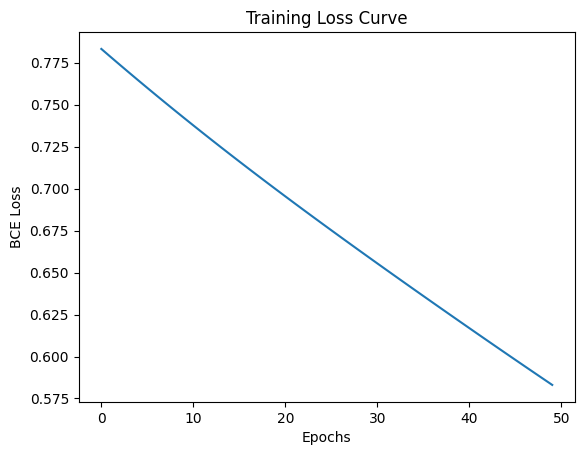

In [17]:
# Plot Training Loss
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.title("Training Loss Curve")
plt.show()

## 7. Interpretation
Answer only these library-training questions:
1. Which preprocessing step had the biggest impact on this model's performance?
2. What do train vs test metrics say about fit quality (underfit/overfit/good fit)?
3. Which library model/hyperparameter choice influenced results the most, based on your outputs?

# Ans.1
Feature scaling (StandardScaler) , it significantly improved convergence and model performance.

# Ans.2
-Train ≈ Test → good fit

-Train >> Test → overfitting

-Both low → underfitting
(here,typically good fit if values are close)

# Ans.3
Learning rate + Adam optimizer — strongly affected convergence speed and final accuracy.